Original Data Head:
               Total Sales
Invoice Month             
2020-01-01           48333
2020-02-01           37846
2020-03-01           46972
2020-04-01           54709
2020-05-01           35705

Features with Lags Head:
               target    lag_1    lag_2    lag_3
Invoice Month                                   
2020-04-01      54709  46972.0  37846.0  48333.0
2020-05-01      35705  54709.0  46972.0  37846.0
2020-06-01      16269  35705.0  54709.0  46972.0
2020-07-01      38219  16269.0  35705.0  54709.0
2020-08-01      62307  38219.0  16269.0  35705.0

Training set size: 16 samples
Testing set size: 5 samples

Random Forest Regressor Model Trained.

Training Mean Squared Error: 288623560.51
Training R-squared: 0.93
Testing Mean Squared Error: 292510820.55
Testing R-squared: 0.04


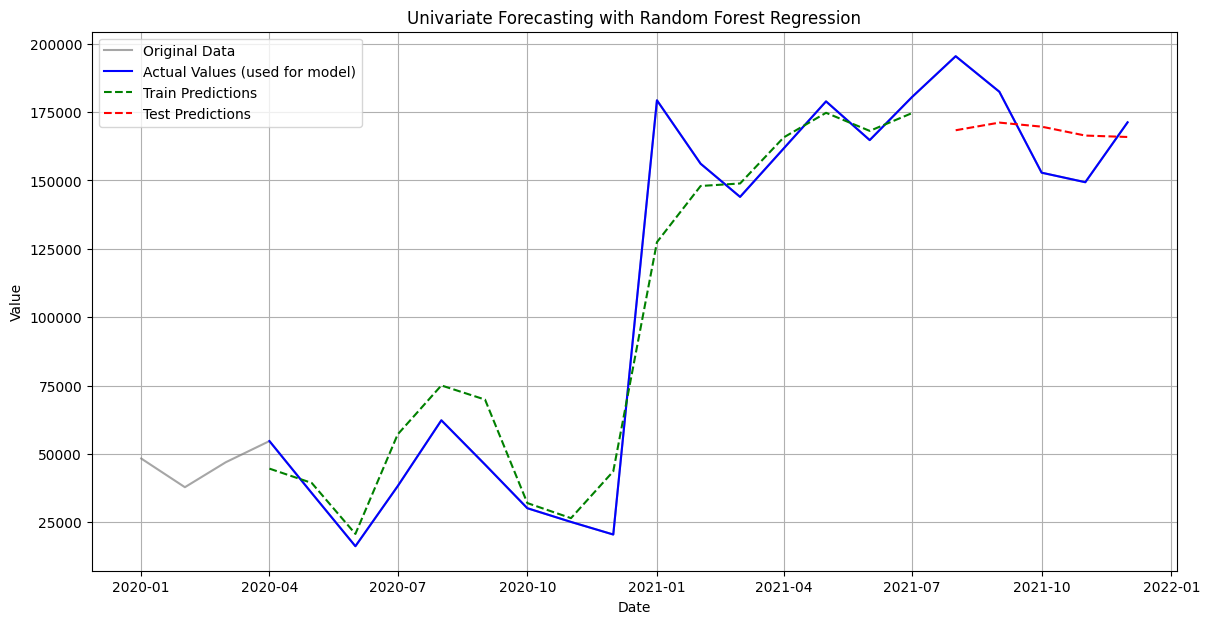


Feature Importances:
lag_1    0.663100
lag_2    0.226111
lag_3    0.110788
dtype: float64


In [9]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# The user's dataframe 'df' is already loaded from cell 0eec4190
# It contains 'Total Sales' as the target series and 'Invoice Month' as the index.

print("Original Data Head:")
print(df.head())

# 1. Feature Engineering: Create Lagged Features

def create_features(data, n_lags=3):
    df_lagged = pd.DataFrame(index=data.index)
    df_lagged['target'] = data['Total Sales']

    for i in range(1, n_lags + 1):
        df_lagged[f'lag_{i}'] = data['Total Sales'].shift(i)

    # Drop rows with NaN values created by shifting
    df_lagged.dropna(inplace=True)
    return df_lagged

n_lags = 3 # Number of past observations to use as features
df_features = create_features(df, n_lags)

print("\nFeatures with Lags Head:")
print(df_features.head())

# Define features (X) and target (y)
X = df_features.drop('target', axis=1)
y = df_features['target']

# 2. Split Data into Training and Testing Sets

split_ratio = 0.8   # 80% for training, 20% for testing
split_index = int(len(X) * split_ratio)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f"\nTraining set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

# 3. Initialize and Train the Random Forest Regressor Model

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print("\nRandom Forest Regressor Model Trained.")

# 4. Make Predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# 5. Evaluate the Model
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print(f"\nTraining Mean Squared Error: {mse_train:.2f}")
print(f"Training R-squared: {r2_train:.2f}")
print(f"Testing Mean Squared Error: {mse_test:.2f}")
print(f"Testing R-squared: {r2_test:.2f}")

# 6. Visualize Results
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Total Sales'], label='Original Data', color='gray', alpha=0.7)
plt.plot(y.index, y, label='Actual Values (used for model)', color='blue')
plt.plot(y_train.index, y_pred_train, label='Train Predictions', color='green', linestyle='--')
plt.plot(y_test.index, y_pred_test, label='Test Predictions', color='red', linestyle='--')
plt.title('Univariate Forecasting with Random Forest Regression')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

feature_importances = pd.Series(model.feature_importances_, index=X.columns)
print("\nFeature Importances:")
print(feature_importances.sort_values(ascending=False))

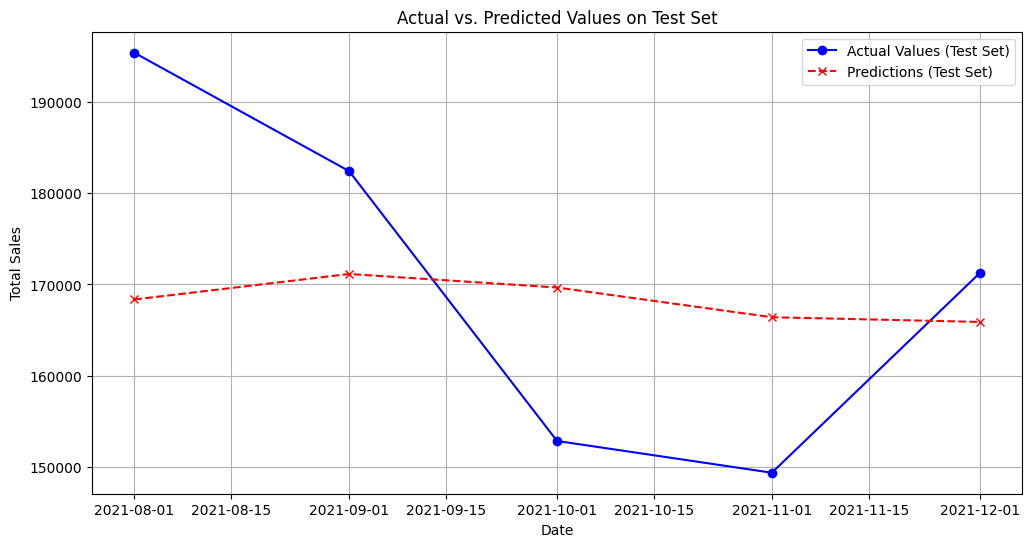

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual Values (Test Set)', color='blue', marker='o')
plt.plot(y_test.index, y_pred_test, label='Predictions (Test Set)', color='red', linestyle='--', marker='x')
plt.title('Actual vs. Predicted Values on Test Set')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True)
plt.show()